# Exploracao do `immigrants_sc.csv`

Notebook para explorar o arquivo consolidado de imigrantes, com visao geral, qualidade das colunas, rankings e graficos.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
candidate_paths = [
    PROJECT_ROOT / 'data' / 'processed' / 'records_clean.csv',
    PROJECT_ROOT / 'output' / 'immigrants_sc.csv',
]
if not any(path.exists() for path in candidate_paths):
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
    candidate_paths = [
        PROJECT_ROOT / 'data' / 'processed' / 'records_clean.csv',
        PROJECT_ROOT / 'output' / 'immigrants_sc.csv',
    ]

CSV_PATH = next((path for path in candidate_paths if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError('Nenhum CSV de imigrantes foi encontrado em data/processed ou output.')
CSV_PATH

WindowsPath('C:/Users/joaop/master/projeto/output/immigrants_sc.csv')

In [2]:
def clean_text(value):
    if value is None:
        return ''
    return re.sub(r'\s+', ' ', str(value)).strip()


def extract_year(value):
    match = re.search(r'(18\\d{2}|19\\d{2}|20\\d{2})', clean_text(value))
    return int(match.group(1)) if match else None


df = pd.read_csv(CSV_PATH, dtype=str).fillna('')
df['document_year_num'] = df['document_year'].map(extract_year)
df['arrival_year_num'] = df['arrival_date'].map(extract_year)
df['departure_year_num'] = df['departure_date'].map(extract_year)

print('rows:', len(df))
print('columns:', len(df.columns))
df.head()

rows: 15246
columns: 32


,record_id,source,source_collection,document_type,person_name_raw,given_names,surnames,normalized_name,sex,age,...,spouse_name,children_names,document_year,page_reference,image_reference,notes,raw_text,document_year_num,arrival_year_num,departure_year_num
0,85f44d7540b0ee3a,joinville.pdf,Arquivo Historico de Joinville - Listas de Imi...,translated_passenger_list_entry,"ANTONI, Carl",Carl,ANTONI,CARL ANTONI,,36 anos,...,,,1850,14,joinville.pdf#page=14,occupation: lavrador; religion: protestante; s...,"ANTONI, Carl: 36 anos, lavrador, Schleswig, pr...",None,None,None
1,2c73e9bb68db401e,joinville.pdf,Arquivo Historico de Joinville - Listas de Imi...,translated_passenger_list_entry,"MONOD, Arthur",Arthur,MONOD,ARTHUR MONOD,,24 anos,...,Lydie,,1850,15,joinville.pdf#page=15,occupation: lavrador; religion: protestantes; ...,"MONOD, Arthur: 24 anos, lavrador, Suíça, c/ mu...",None,None,None
2,0c1d68343e546c3a,joinville.pdf,Arquivo Historico de Joinville - Listas de Imi...,translated_passenger_list_entry,"KOHN, Aug.",Aug.,KOHN,AUG KOHN,,37 anos,...,Marg. Elisabeth,Cath. Johanna; Franz August; Henr. Franziska E...,1850,15,joinville.pdf#page=15,occupation: lavrador; religion: protestantes; ...,"KOHN, Aug.: 37 anos, lavrador, Hamburgo, † 17/...",None,None,None
3,db9c697bf599236d,joinville.pdf,Arquivo Historico de Joinville - Listas de Imi...,translated_passenger_list_entry,"RAUCH, Bernh. Mart. Friedr.",Bernh. Mart. Friedr.,RAUCH,BERNH MART FRIEDR RAUCH,,43 anos,...,Friederike,Bella; Emma; Adele; Eduard; Ida; Mina,1850,15,joinville.pdf#page=15,occupation: candidato a teólogo; religion: pro...,"RAUCH, Bernh. Mart. Friedr.: 43 anos, candidat...",None,None,None
4,e93287cb8bb94167,joinville.pdf,Arquivo Historico de Joinville - Listas de Imi...,translated_passenger_list_entry,"POSCHAAN, Bernhard",Bernhard,POSCHAAN,BERNHARD POSCHAAN,,20 anos,...,,,1850,15,joinville.pdf#page=15,occupation: lavrador; religion: protestante; s...,"POSCHAAN, Bernhard: 20 anos, lavrador, Hamburg...",None,None,None


In [3]:
year_series = df['document_year_num'].dropna()

overview = {
    'rows': len(df),
    'unique_record_id': df['record_id'].nunique(),
    'duplicate_record_id': int(df['record_id'].duplicated().sum()),
    'year_min': int(year_series.min()) if not year_series.empty else None,
    'year_max': int(year_series.max()) if not year_series.empty else None,
    'sources': df['source'].nunique(),
    'document_types': df['document_type'].nunique(),
}

pd.Series(overview)

rows                   15246.0
unique_record_id       15245.0
duplicate_record_id        1.0
year_min                   NaN
year_max                   NaN
sources                    2.0
document_types             2.0
dtype: float64

In [4]:
column_rows = []
base_columns = [c for c in df.columns if not c.endswith('_num')]

for column in base_columns:
    series = df[column].astype(str)
    non_empty = int(series.str.strip().ne('').sum())
    missing = int(len(series) - non_empty)
    unique_non_empty = int(series[series.str.strip().ne('')].nunique())
    samples = series[series.str.strip().ne('')].drop_duplicates().head(3).tolist()
    column_rows.append({
        'column': column,
        'non_empty': non_empty,
        'missing': missing,
        'fill_rate_pct': round((non_empty / len(df)) * 100, 2),
        'unique_non_empty': unique_non_empty,
        'sample_values': ' | '.join(clean_text(sample) for sample in samples),
    })

column_summary = pd.DataFrame(column_rows).sort_values(
    ['fill_rate_pct', 'column'], ascending=[False, True], kind='stable'
)

column_summary.head(12)

,column,non_empty,missing,fill_rate_pct,unique_non_empty,sample_values
3,document_type,15246,0,100.00,2,translated_passenger_list_entry | onomastic_in...
24,document_year,15246,0,100.00,58,1850 | 1851 | 1852
26,image_reference,15246,0,100.00,592,joinville.pdf#page=14 | joinville.pdf#page=15 ...
7,normalized_name,15246,0,100.00,14205,CARL ANTONI | ARTHUR MONOD | AUG KOHN
25,page_reference,15246,0,100.00,948,14 | 15 | 16
4,person_name_raw,15246,0,100.00,14264,"ANTONI, Carl | MONOD, Arthur | KOHN, Aug."
28,raw_text,15246,0,100.00,15148,"ANTONI, Carl: 36 anos, lavrador, Schleswig, pr..."
0,record_id,15246,0,100.00,15245,85f44d7540b0ee3a | 2c73e9bb68db401e | 0c1d6834...
1,source,15246,0,100.00,2,joinville.pdf | sc1.pdf
2,source_collection,15246,0,100.00,2,Arquivo Historico de Joinville - Listas de Imi...


In [5]:
column_summary.tail(12)

,column,non_empty,missing,fill_rate_pct,unique_non_empty,sample_values
10,birth_year_est,10880,4366,71.36,120,1814 | 1826 | 1813
17,arrival_date,9752,5494,63.96,275,09/03/1851 | 05/12/1852 | 20/05/1852
13,origin_city,9734,5512,63.85,3868,Schleswig | Braunschweig | Dassel
14,origin_country,9585,5661,62.87,551,Suíça | Hamburgo | Prússia
16,departure_date,7774,7472,50.99,181,10/12/1850 | 20/09/1852 | 18/03/1852
18,arrival_port,4703,10543,30.85,15,São Francisco do Sul | S. Francisco | porto de...
22,spouse_name,3694,11552,24.23,516,Lydie | Marg. Elisabeth | Friederike
23,children_names,3544,11702,23.25,2915,Cath. Johanna; Franz August; Henr. Franziska E...
8,sex,2580,12666,16.92,2,F | M
11,nationality,425,14821,2.79,12,Brasileiro | Austríaco | Francês


In [6]:
source_counts = df['source'].value_counts().rename_axis('source').reset_index(name='count')
document_type_counts = df['document_type'].value_counts().rename_axis('document_type').reset_index(name='count')

display(source_counts)
display(document_type_counts)

,source,count
0,joinville.pdf,10698
1,sc1.pdf,4548


,document_type,count
0,translated_passenger_list_entry,10698
1,onomastic_index_entry,4548


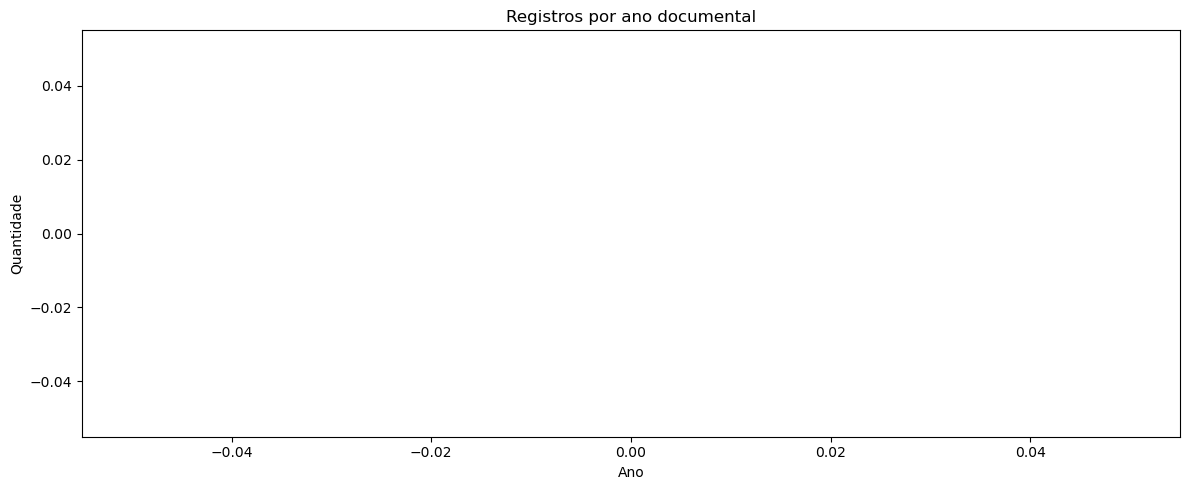

,year,count


In [7]:
year_table = (
    df['document_year_num']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('year')
    .reset_index(name='count')
)

plt.figure(figsize=(12, 5))
plt.plot(year_table['year'], year_table['count'], color='#1f6b4f', linewidth=2)
plt.scatter(year_table['year'], year_table['count'], color='#f4a259', s=16, zorder=3)
plt.title('Registros por ano documental')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

year_table.head()

In [8]:
top_destinations = (
    df['destination_locality']
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
    .rename_axis('destination_locality')
    .reset_index(name='count')
    .head(20)
)

top_surnames = (
    df['surnames']
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
    .rename_axis('surnames')
    .reset_index(name='count')
    .head(20)
)

top_ships = (
    df['ship_name']
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
    .rename_axis('ship_name')
    .reset_index(name='count')
    .head(20)
)

display(top_destinations)
display(top_surnames)
display(top_ships)

,destination_locality,count
0,Colônia,2208
1,Dona Francisca,1713
2,Itajaí,1615
3,Blumenau,1357
4,Dona Francisca e Blumenau,1243
5,Brusque,683
6,São Francisco,532
7,São Bento,307
8,Colônia Brusque,152
9,Col.P.Dom Pedro,133


,surnames,count
0,MÜLLER,148
1,Ass.,103
2,SCHMIDT,90
3,SILVA,86
4,FISCHER,58
5,KRÜGER,56
6,HOFFMANN,54
7,BECKER,51
8,SCHNEIDER,49
9,MEYER,47


,ship_name,count
0,?,879
1,VALPARAISO,560
2,Paquete Laguna,520
3,FRANKLIN,516
4,SANTOS,495
5,MONTEVIDEO,393
6,BAHIA,324
7,RALEIGH,253
8,ARGENTINA,240
9,Joinville,230


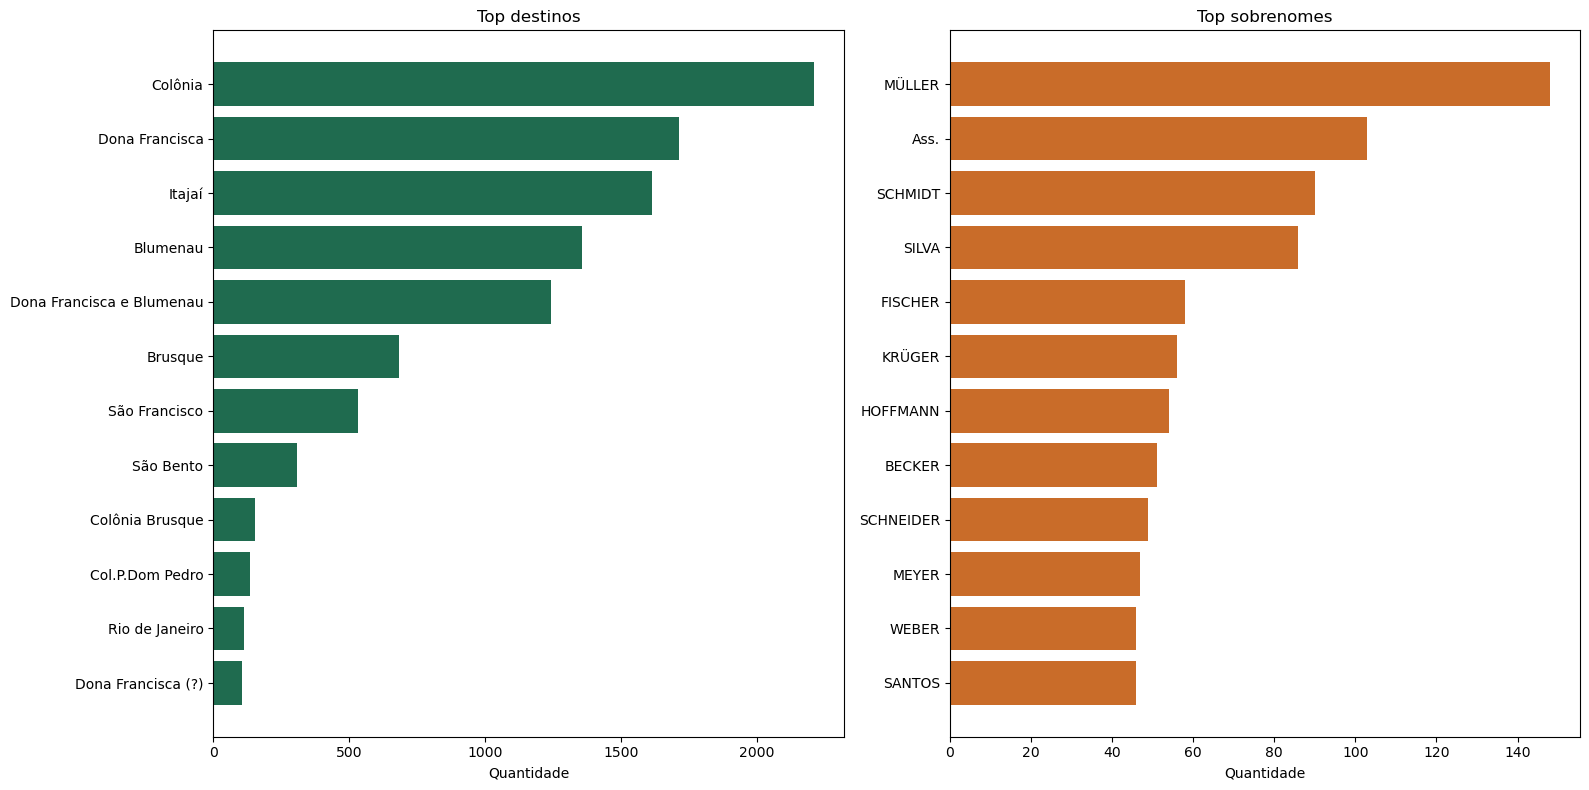

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top_destinations['destination_locality'].iloc[:12][::-1], top_destinations['count'].iloc[:12][::-1], color='#1f6b4f')
axes[0].set_title('Top destinos')
axes[0].set_xlabel('Quantidade')

axes[1].barh(top_surnames['surnames'].iloc[:12][::-1], top_surnames['count'].iloc[:12][::-1], color='#c96c29')
axes[1].set_title('Top sobrenomes')
axes[1].set_xlabel('Quantidade')

plt.tight_layout()
plt.show()

In [10]:
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'exploration_from_notebook'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

column_summary.to_csv(OUTPUT_DIR / 'column_summary.csv', index=False, encoding='utf-8-sig')
source_counts.to_csv(OUTPUT_DIR / 'records_by_source.csv', index=False, encoding='utf-8-sig')
document_type_counts.to_csv(OUTPUT_DIR / 'records_by_document_type.csv', index=False, encoding='utf-8-sig')
year_table.to_csv(OUTPUT_DIR / 'records_by_year.csv', index=False, encoding='utf-8-sig')
top_destinations.to_csv(OUTPUT_DIR / 'top_destination_locality.csv', index=False, encoding='utf-8-sig')
top_surnames.to_csv(OUTPUT_DIR / 'top_surnames.csv', index=False, encoding='utf-8-sig')
top_ships.to_csv(OUTPUT_DIR / 'top_ship_name.csv', index=False, encoding='utf-8-sig')

print('Arquivos salvos em:', OUTPUT_DIR)

Arquivos salvos em: C:\Users\joaop\master\projeto\output\exploration_from_notebook
